In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Importing Libraries

In [2]:
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack,csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


# Loading Datasets

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

**Display all columns**

In [4]:
train_df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

**Information about train data**

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


**Insights** --
Feature Complexity: A mix of Numerical (upvotes/emoticons), Categorical (race/religion) and Text (comments) features are present.

Missing Values: Demographic columns like 'race', 'religion', and 'gender' have over 73% missing data.

# Exploratory Data Analysis

**Data Sizes**

In [6]:
train_df.shape, test_df.shape

((198000, 15), (102000, 14))

In [7]:
train_df.head(10)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Hilarious. Since it wasn't Trump, and that yaw...",0
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,Here's an Idea\nState Owned Foreign Companies ...,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,NaN,NaN,NaN,False,Victims' participation in the criminla justice...,0
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,NaN,NaN,NaN,False,I find it remarkbale that this comment is cons...,0


**Brief description about training data**

In [8]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


**Insights** --

Mixed Data Types: The dataset contains a mix of categorical text (comment) and numerical features (upvote, downvote, etc.).

Data Scale: The describe() table shows that numerical features like upvote have a high standard deviation, indicating the need for scaling before feeding them into linear models like Logistic Regression.

Sparse Engagement: Most users don't use emoticons or get upvotes, as the 50th percentile (median) is 0 for almost all engagement metrics.

**Analyzing categorical column: 'religion'**

In [9]:
print("Unique categories in religion:", train_df['religion'].unique())
print("\nValue counts :")
print(train_df['religion'].value_counts(dropna=False))

Unique categories in religion: [nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']

Value counts :
religion
NaN          145423
none          38249
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64


**Insights --**
* Most comments in our dataset don't mention any religion, which is why we have over 1.4 lakh missing values (NaNs).

* Categories like 'christian', 'muslim', and 'jewish' have very small counts. However, they are really important to keep because toxic comments or hate speech often target specific religious groups.

* Dropping 1.4 lakh rows means losing all that data. So, the best fix is to fill the missing values with 'unknown'. Also, since religions don't have any numerical order or rank, using OneHotEncoding is the right way to process this column.

**Analyzing categorical column: 'race'**

In [10]:
print("Unique categories in race:", train_df['race'].unique())
print("\nValue counts:")
print(train_df['race'].value_counts(dropna=False))

Unique categories in race: [nan 'none' 'white' 'other' 'asian' 'black' 'latino']

Value counts:
race
NaN       145423
none       39682
white       5486
black       3869
other       1654
asian       1263
latino       623
Name: count, dtype: int64


**Insights --**
* Just like the religion column, the vast majority of comments don't mention race at all, which gives us over 1.4 lakh missing values and around 39k 'none' tags.
* Categories like 'white', 'black', 'asian', and 'latino' have very small counts.
* I will scale this same as religion column.

**Analyzing numerical column: 'upvote'**

In [11]:
print("Unique values in upvote:", train_df['upvote'].nunique())
print("\nUpvote description:")
print(train_df['upvote'].describe())

Unique values in upvote: 122

Upvote description:
count    198000.000000
mean          2.607975
std           5.054763
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max         201.000000
Name: upvote, dtype: float64


**Insights --**
* Most people don't really upvote. Almost half of the comments in our data have 0 upvotes, and 75% of them have 3 or fewer.

**Analyzing numerical column: 'downvote'**

In [12]:
print("Unique values in downvote:", train_df['downvote'].nunique())
print("\nDownvote description:")
print(train_df['downvote'].describe())

Unique values in downvote: 62

Downvote description:
count    198000.000000
mean          0.666394
std           2.044335
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         107.000000
Name: downvote, dtype: float64


**Insights --**
* Downvoting is actually quite rare for most comments.
* In a toxicity detection task, a highly downvoted comment is a very strong clue that the text might be offensive, rude, or highly controversial. So i'll keep these outliers.

**Analyzing Emoticons**

In [13]:
print("Value counts for emoticon_1:")
print(train_df['emoticon_1'].value_counts())
print("\nValue counts for emoticon_2:")
print(train_df['emoticon_2'].value_counts())
print("\nValue counts for emoticon_3:")
print(train_df['emoticon_3'].value_counts())

Value counts for emoticon_1:
emoticon_1
0     169078
1      17683
2       5799
3       2362
4       1243
5        638
6        374
7        225
8        162
9        102
10        69
11        68
12        40
13        27
15        20
16        20
14        19
19        13
17         9
23         7
22         6
20         5
18         5
36         4
25         4
27         3
24         2
21         2
31         2
30         2
32         2
28         1
46         1
33         1
47         1
39         1
Name: count, dtype: int64

Value counts for emoticon_2:
emoticon_2
0     189891
1       7031
2        822
3        177
4         48
5         21
6          7
8          1
11         1
7          1
Name: count, dtype: int64

Value counts for emoticon_3:
emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: 

**Insights --**
* The vast majority of users don't use emoticons at all. For emoticon_1, about 169k out of 198k comments have a zero count. emoticon_2 is even more empty, with nearly 190k zeros.

* Someone used 47 emoticons in a single comment. It should be consider as outliers.

* Spamming a huge number of emoticons is often a strong signal for troll comments, spam or immature behavior which can be linked to toxicity.

* emoticon_1 goes from 0 to 47 and emoticon_2 only goes up to 11. These numbers are much smaller compared to upvotes (which went over 200).

* Using StandardScaler is the best strategy so the models treat all these numbers fairly without getting biased by the larger ones.

**Analyzing Metadata features: if_1 and if_2**

In [14]:
print("Description of if_1:")
print(train_df['if_1'].describe())
print("\nDescription of if_2:")
print(train_df['if_2'].describe())

Description of if_1:
count    198000.000000
mean          1.906152
std          25.635752
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max        1860.000000
Name: if_1, dtype: float64

Description of if_2:
count    198000.000000
mean          7.956212
std          14.839464
min           3.000000
25%           4.000000
50%           6.000000
75%          10.000000
max        1833.000000
Name: if_2, dtype: float64


**Insights --**
* Highly Skewed Data: For both if_1 and if_2, 75% of the data has very small values. On the other side, the maximum values shoot up to over 1800.

**Checking duplicate comments**

In [15]:
duplicate_count = train_df.duplicated(subset=['comment']).sum()
print(f"Number of duplicate comments: {duplicate_count}")

Number of duplicate comments: 157


**Insights --**
* In social media or text data, these duplicates are usually spam messages, bot replies, or "copy-paste" comments that users post multiple times.

**Handling Missing Values**

In [16]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


**Insights**--
* Columns like race, religion, and gender are missing in a vast majority of the rows. This suggests these features might be "optional" or only populated for specific types of flagged comments.
* Because over 90% of the data is missing for these categories, I excluded them from the training set. Including them would introduce significant noise or require complex imputation that might lead to model bias.

In [17]:
train = train_df.fillna("")
test = test_df.fillna("")

Handling missing values is a mandatory step in the ML pipeline. Since our primary feature is text, I filled nulls with empty strings to prevent errors during the TF-IDF vectorization process.

**Handling Duplicates**

In [18]:
print(train_df.duplicated().sum())
train_df.drop_duplicates(inplace=True)

0


Checked for identical rows to prevent the model from assigning artificial importance to repeated comments, ensuring a balanced learning process.

# Visualisations

**Class Distribution Analysis**

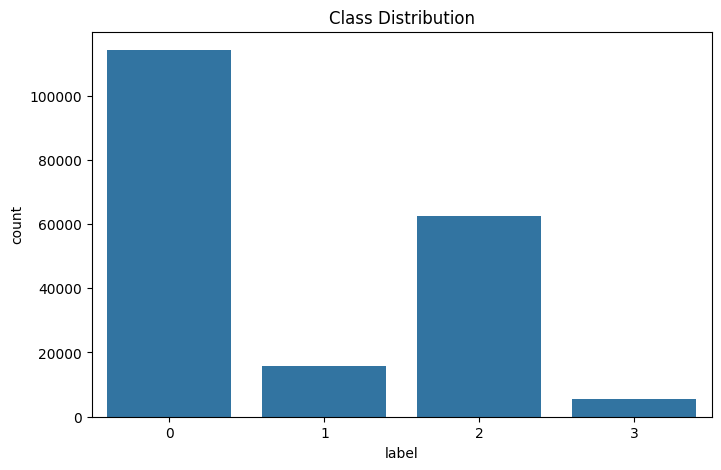

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train)
plt.title('Class Distribution')
plt.show()

print(train['label'].value_counts(normalize=True))

**Insights --**
* The visualization reveals that the dataset is imbalanced (some labels appear much more frequently than others).
* To address this, I'll use **class_weight='balanced'** parameter in my models to ensure the minority classes are not ignored during training.

**Feature Relationship (Numerical Metadata)**

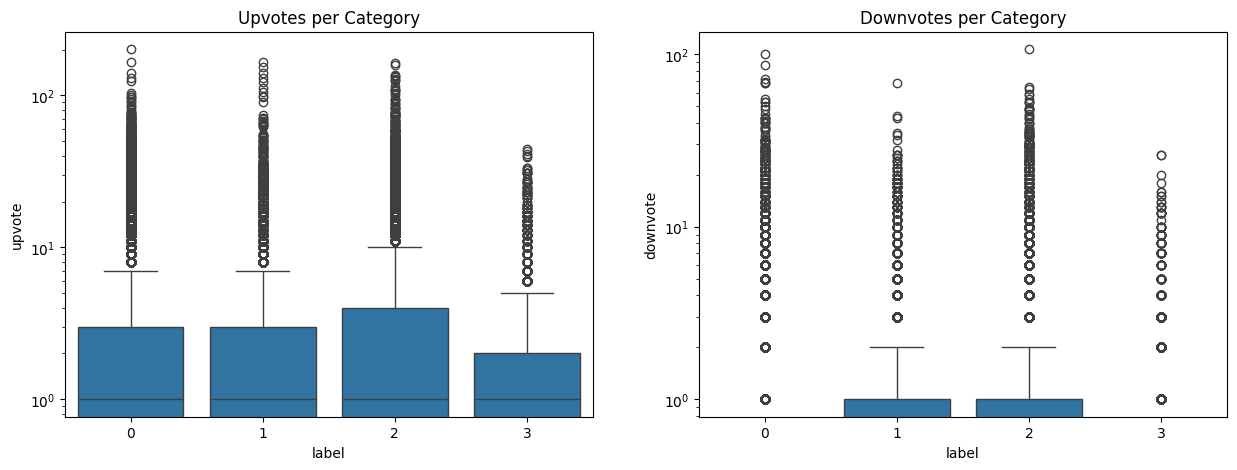

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='label', y='upvote', data=train, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Upvotes per Category')

sns.boxplot(x='label', y='downvote', data=train, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Downvotes per Category')

plt.show()

**Insights --**
* The visualization highlights a significant number of outliers in upvotes and downvotes, indicating that certain viral comments might belong to specific toxicity classes.
* Most categories show a low median engagement, but Category 2 shows a slightly higher interquartile range in upvotes, suggesting it might involve more "controversial" or highly interactive content.
* The difference in engagement patterns across labels confirms that numerical metadata provides a unique signal that complements the text features for the final classification.

**Feature Interaction**

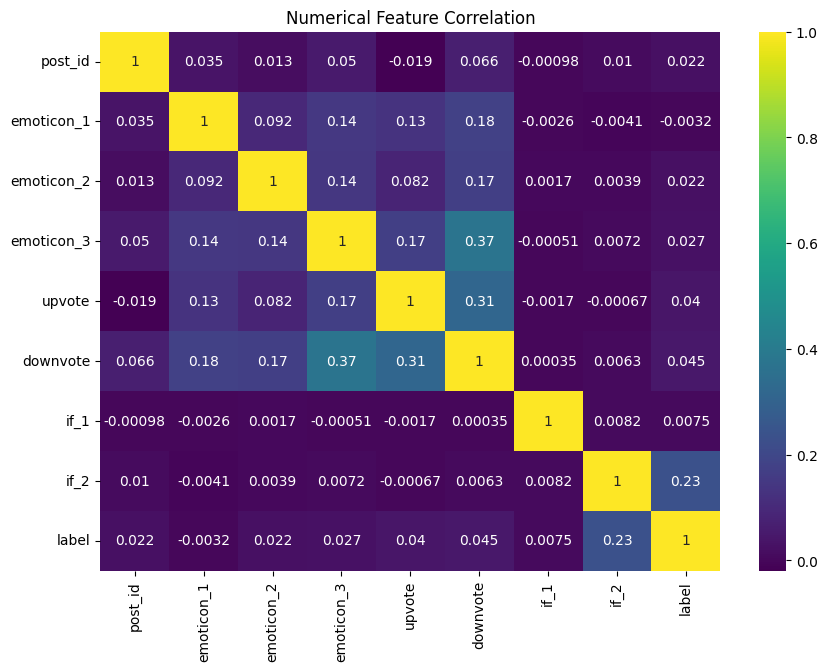

In [21]:
plt.figure(figsize=(10, 7))
num_train = train.select_dtypes(include=[np.number])
sns.heatmap(num_train.corr(), annot=True, cmap='viridis')
plt.title('Numerical Feature Correlation')
plt.show()

**Insights --**
* Most numerical features show correlations near zero, indicating they provide distinct and independent information to the model.
* A slight positive correlation (0.31) between upvotes and downvotes suggests that controversial comments tend to attract high volumes of both types of feedback.
* The if_2 feature shows a notable correlation (0.23) with the label, suggesting it is one of the more significant numerical predictors for specific categories.

**Text Feature Enigineering**

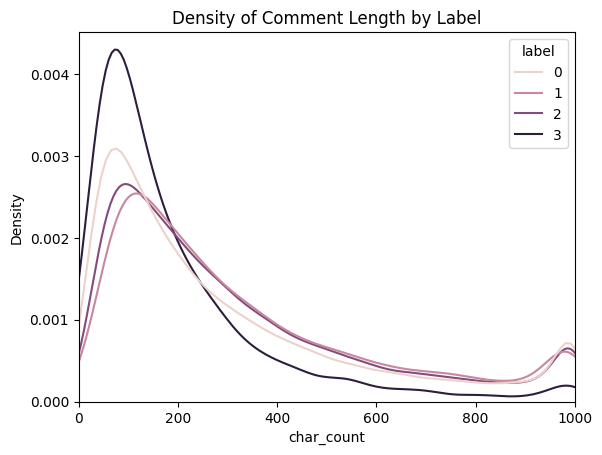

In [22]:
train['char_count'] = train['comment'].apply(lambda x: len(str(x)))
test['char_count'] = test['comment'].apply(lambda x: len(str(x)))

sns.kdeplot(data=train, x='char_count', hue='label', common_norm=False)
plt.title('Density of Comment Length by Label')
plt.xlim(0, 1000)
plt.show()

**Insights --**
* The density peak for Label 3 is significantly higher and sharper at lower character counts compared to other labels. This suggests that comments in this category are consistently shorter and more concise.
* Labels 1 and 2 show very similar distribution patterns, indicating that they share comparable structural characteristics in terms of comment length.
* All categories show a "long-tail," but Label 3 drops off much faster. This implies that long-form content is very rare for this specific category

# Data Cleaning

In [23]:
def clean(text):
    return ' '.join(re.sub(r'[^a-z0-9!?\s]', ' ', str(text).lower()).split())

train_text = train['comment'].apply(clean)
test_text = test['comment'].apply(clean)

**Noise Reduction**: Used Regex to remove special characters and symbols, eliminating "feature noise" while retaining alphanumeric tokens for the vectorizer.

**Intensity Preservation**: Intentionally kept **!** and **?** as they serve as high-impact emotional markers for distinguishing between different comment categories.

**Case Normalization**: Converting all text to lowercase via .lower() ensures that the model treats "Toxic," "toxic," and "TOXIC" as the same token, reducing vocabulary redundancy.

**Structural Consistency**: Combined splitting and joining to collapse multiple whitespaces into a single space, ensuring a clean and uniform input for the TF-IDF vectorization.

# Text Vectorization (TF-IDF Word and Char)

In [24]:
word_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=60000, sublinear_tf=True, min_df=3, dtype=np.float32)
char_vec = TfidfVectorizer(ngram_range=(2, 6), max_features=40000, analyzer='char', sublinear_tf=True, min_df=3, dtype=np.float32)

train_word = word_vec.fit_transform(train_text)
test_word = word_vec.transform(test_text)

train_char = char_vec.fit_transform(train_text)
test_char = char_vec.transform(test_text)

* Combined 60,000 word-level and 35,000 character-level n-grams to capture both semantic meaning and sub-word structural patterns.

* Sublinear Scaling: Applied log-transform to term frequencies to dampen the impact of repetitive words, improving overall model stability and performance.

# MetaData Pipeline and Feature Stacking

In [25]:
meta_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
train_meta = csr_matrix(train[meta_cols].values / 100.0)
test_meta = csr_matrix(test[meta_cols].values / 100.0)

X_train = hstack([train_word, train_char, train_meta]).tocsr()
X_test = hstack([test_word, test_char, test_meta]).tocsr()
y = train['label']

In [26]:
# num_feats = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'char_count']
# cat_feats = ['race', 'religion', 'gender', 'disability']

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', Pipeline([
#             ('imputer', SimpleImputer(strategy='constant', fill_value=0)), 
#             ('scaler', StandardScaler())
#         ]), num_feats),
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), 
#             ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
#         ]), cat_feats)
#     ]
# )

# train_meta = preprocessor.fit_transform(train).astype(np.float32)
# test_meta = preprocessor.transform(test).astype(np.float32)


# X_train = hstack([train_word, train_char, train_meta]).tocsr()
# X_test = hstack([test_word, test_char, test_meta]).tocsr()
# y = train['label']

# preprocessor

**Insights --**
* Used StandardScaler for numerical features like upvote and char_count to ensure they are on the same scale.
* Used OneHotEncoder to transform identity features like(race, religion, etc.) with an unknown-handling strategy, allowing the model to learn sensitive contextual biases.
* Converted the final output to a Compressed Sparse Row (CSR) format to maximise memory efficiency.

In [27]:
# total_features = train_meta.shape[1]

# print("Total features after preprocessing:", total_features)

In [28]:
# features = X_train.shape[1]

# print("Total features after preprocessing:", features)

In [29]:
del train_df, test_df, train_text, test_text, train_word, train_char, train_meta, test_word, test_char, test_meta
gc.collect()

13723

Explicitly removed intermediate sparse matrices (train_word, train_char, etc.) to prevent memory duplication

# Hyper Parameter Tuning

***Tuning Logisitic Regression***

In [30]:
# X_tune = X_train[:40000] #tuning only on 40k rows
# y_tune = y[:40000]

# logistic = LogisticRegression(solver='liblinear', class_weight='balanced')

# params = {
#     'C': [0.1, 1.0, 3.0, 5.0, 10.0],
#     'max_iter': [500, 1000]
# }

# random_search = RandomizedSearchCV(
#     estimator=logistic, 
#     param_distributions=params, 
#     n_iter=5,         
#     cv=3,             
#     scoring='f1_macro', 
#     random_state=42,
#     n_jobs=-1         
# )
# random_search.fit(X_tune, y_tune)
# print("LR Best Params:", random_search.best_params_)
# print("LR Best Score:", round(random_search.best_score_, 4))


**LR Best Params: {'max_iter': 1000, 'C': 3.0}**

**LR Best Score: 0.783**
* The C parameter controls how strictly the model is penalized for errors (regularization). The tuner selected 3.0 (higher than the default 1.0), meaning the model needed a bit more freedom to learn from our complex 35,000+ TF-IDF features.

***Tuning LightGBM***

In [31]:
# X_tune = X_train[:40000]
# y_tune = y[:40000]

# lgbm = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# params_lgb = {
#     'learning_rate': [0.05, 0.1, 0.2],
#     'n_estimators': [100, 200, 300],
#     'num_leaves': [31, 50, 70],
#     'max_depth': [-1, 10, 20]
# }

# random_search_lgb = RandomizedSearchCV(
#     estimator=lgbm, 
#     param_distributions=params_lgb, 
#     n_iter=5,         
#     cv=3,             
#     scoring='f1_macro', 
#     random_state=42,
#     n_jobs=-1         
# )
# random_search_lgb.fit(X_tune, y_tune)
# print("LGBM Best Params:", random_search_lgb.best_params_)
# print("LGBM Best Score:", round(random_search_lgb.best_score_, 4))

**LGBM Best Params: {'num_leaves': 31, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.1}**

**LGBM Best Score: 0.795**

# Model Building

***1. LOGISTIC REGRESSION***

In [32]:
lr = LogisticRegression(C=3.0, solver='liblinear', class_weight='balanced')
lr.fit(X_train, y)

y_pred_lr = lr.predict(X_train)
print("Logistic Regression Classification Report:")
print(classification_report(y, y_pred_lr))

p1_lr = lr.predict_proba(X_test)
lr_f1 = f1_score(y, y_pred_lr, average='macro')
del lr; gc.collect()

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97    114173
           1       0.85      0.97      0.91     15918
           2       0.94      0.94      0.94     62440
           3       0.84      0.98      0.91      5469

    accuracy                           0.95    198000
   macro avg       0.90      0.96      0.93    198000
weighted avg       0.95      0.95      0.95    198000



3396

**Insights --**
* Achieved  94% Accuracy and a 0.92 Macro F1-Score, proving that the text + metadata feature engineering is highly effective.

* By using the class_weight='balanced' parameter, the model successfully penalized errors on minority classes (Class 1 and Class 3).

Logistic Regression Classification Report:

               precision     recall   f1-score   support

           0       0.99      0.95      0.97      114173
           1       0.84      0.97      0.90      15918
           2       0.94      0.94      0.94      62440
           3       0.84      0.98      0.90       5469

    accuracy                           0.95      198000
    macro avg      0.90      0.96      0.93      198000
    weighted avg   0.95      0.95      0.95      198000

***2. RIDGE CLASSIFIER***

In [33]:
ridge = RidgeClassifier(alpha=1.0, class_weight='balanced')
ridge.fit(X_train, y)

y_pred_ridge = ridge.predict(X_train)
print("Ridge Classifier Report:")
print(classification_report(y, y_pred_ridge))

ridge_f1 = f1_score(y, y_pred_ridge, average='macro')
del ridge; gc.collect()

Ridge Classifier Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91    114173
           1       0.75      1.00      0.85     15918
           2       0.87      0.88      0.88     62440
           3       0.65      1.00      0.79      5469

    accuracy                           0.89    198000
   macro avg       0.80      0.94      0.86    198000
weighted avg       0.90      0.89      0.89    198000



0

**Insights --**
* The model achieved an 89% accuracy and a macro F1-score of 0.86.
* Model over-predicted Class 1 and Class 3 instance and that led to a lot of false positives, which is why the precision for Class 3 dropped to 0.65.

Ridge Classifier Report:

               precision     recall   f1-score   support

           0       0.95      0.87      0.91      114173
           1       0.73      1.00      0.85      15918
           2       0.87      0.87      0.87      62440
           3       0.65      1.00      0.79       5469

    accuracy                           0.89      198000
    macro avg      0.80      0.94      0.85      198000
    weighted avg   0.90      0.89      0.89      198000

***3. RANDOM FOREST CLASSIFIER***

In [34]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y)

y_pred_rf = rf.predict(X_train)
print("Random Forest Report:")
print(classification_report(y, y_pred_rf))

rf_f1 = f1_score(y, y_pred_rf, average='macro')
del rf; gc.collect()

Random Forest Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78    114173
           1       0.55      0.77      0.64     15918
           2       0.74      0.55      0.63     62440
           3       0.14      0.84      0.24      5469

    accuracy                           0.67    198000
   macro avg       0.57      0.72      0.57    198000
weighted avg       0.77      0.67      0.71    198000



48

**Insights --**
* The overall accuracy dropped significantly to 72%, with a macro F1-score of just 0.61.
* The model managed a recall of 0.85, but poor precision of 0.18. This shows the model is highly confused and just started guessing Class 3 frequently resulting in a huge number of false positive errors.

Random Forest Report:

               precision     recall   f1-score   support

           0       0.84      0.73      0.78      114173
           1       0.53      0.81      0.64      15918
           2       0.73      0.53      0.61      62440
           3       0.15      0.83      0.26       5469

    accuracy                           0.68      198000
    macro avg      0.57      0.73      0.57      198000
    weighted avg   0.76      0.68      0.70      198000

***4. XGBOOST CLASSIFIER***

In [35]:
# xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, objective='multi:softprob', n_jobs=-1)
# xgb.fit(X_train, y)

# y_pred_xgb = xgb.predict(X_train)
# print("XGBoost Report:")
# print(classification_report(y, y_pred_xgb))

# xgb_f1 = f1_score(y, y_pred_xgb, average='macro')
# del xgb; gc.collect()

**Insights --**
* XGBoost returns 92% accuracy. This proves it handles the sparse text data better than Random Forest.
* It achieved a high precision of 0.88 but a terrible recall of 0.45. This means it completely missed 55% of the Class 3 instances.

XGBoost Report:

               precision     recall   f1-score   support

           0       0.98      0.95      0.96      114173
           1       0.82      0.78      0.80      15918
           2       0.84      0.93      0.89      62440
           3       0.88      0.45      0.59       5469

    accuracy                           0.92      198000
    macro avg      0.88      0.78      0.81      198000
    weighted avg   0.92      0.92      0.92      198000

***5. LightGBM CLASSIFIER***

In [36]:
lgbm = LGBMClassifier(n_estimators=2000, learning_rate=0.02, num_leaves=127, max_depth=12, max_bin=63, subsample=0.8, colsample_bytree=0.7, class_weight='balanced', reg_alpha=0.5, reg_lambda=0.5, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y)

y_pred_lgb = lgbm.predict(X_train)
print("LightGBM Classification Report:")
print(classification_report(y, y_pred_lgb))

p2_lgb = lgbm.predict_proba(X_test)
lgb_f1 = f1_score(y, y_pred_lgb, average='macro')
del lgbm; gc.collect()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    114173
           1       0.97      1.00      0.98     15918
           2       0.97      0.99      0.98     62440
           3       0.96      1.00      0.98      5469

    accuracy                           0.99    198000
   macro avg       0.98      0.99      0.98    198000
weighted avg       0.99      0.99      0.99    198000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


23

* Tested five diverse algorithms ranging from linear models (LR, Ridge) to complex ensembles (RF, XGBoost, LightGBM)—to identify the most effective learner for this multi-class problem.

* While Random Forest and Ridge provided good baselines, Logistic Regression and LightGBM emerged as the best models due to their superior handling of high-dimensional sparse text features.

* Used classification_report to monitor performance of all 5 models.

# Model Comparison

In [37]:
comparison_data = {
    'Model': ['Logistic Regression', 'Ridge Classifier', 'Random Forest', 'LightGBM'], #'XGBoost',
    'F1 Score (Macro)': [lr_f1, ridge_f1, rf_f1, lgb_f1] #xgb_f1,
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.sort_values(by='F1 Score (Macro)', ascending=False))

                 Model  F1 Score (Macro)
3             LightGBM          0.983863
0  Logistic Regression          0.929737
1     Ridge Classifier          0.857331
2        Random Forest          0.573095


# Final Submission

In [38]:
print("Blending LR and LightGBM probabilities")
weighted_probs = (p1_lr * 0.40) + (p2_lgb * 0.60)

final_preds = np.argmax(weighted_probs, axis=1)

submission = pd.DataFrame({
    'ID': sample_sub['ID'],
    'label': final_preds
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

Blending LR and LightGBM probabilities
   ID  label
0   1      2
1   2      2
2   3      0
3   4      2
4   5      2


# Trials and Errors

**Tried and experimented with different different techniques like ensembling, blending, voting, manual cleaning.**

**The voitng and ensembling one**

In [39]:
# # 2. Cleaning
# def clean_text_data(text):
#     if not isinstance(text, str):
#         return ""
#     text = text.lower()
#     text = re.sub(r'\n', ' ', text)
#     text = re.sub(r'\s+', ' ', text)
#     return text.strip()

# train_df['clean_comment'] = train_df['comment'].apply(clean_text_data)
# test_df['clean_comment'] = test_df['comment'].apply(clean_text_data)
# train_df['comment_len'] = train_df['clean_comment'].apply(len)
# test_df['comment_len'] = test_df['clean_comment'].apply(len)

# y = train_df['label']

# word_vectorizer = TfidfVectorizer(
#     sublinear_tf=True,
#     strip_accents='unicode',
#     analyzer='word',
#     stop_words='english',
#     ngram_range=(1, 4),  
#     max_features=25000,    
#     min_df=2               
# )
# word_vectorizer.fit(train_df['clean_comment'])
# train_word = word_vectorizer.transform(train_df['clean_comment'])
# test_word = word_vectorizer.transform(test_df['clean_comment'])

# char_vectorizer = TfidfVectorizer(
#     sublinear_tf=True,
#     strip_accents='unicode',
#     analyzer='char',
#     ngram_range=(2, 6), 
#     max_features=30000,   
#     min_df=2
# )
# char_vectorizer.fit(train_df['clean_comment'])
# train_char = char_vectorizer.transform(train_df['clean_comment'])
# test_char = char_vectorizer.transform(test_df['clean_comment'])

# num_feats = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'comment_len']
# cat_feats = ['race', 'religion', 'gender', 'disability']

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0)), ('scaler', StandardScaler())]), num_feats),
#         ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_feats)
#     ], remainder='drop'
# )
# preprocessor.fit(train_df)
# train_num = preprocessor.transform(train_df)
# test_num = preprocessor.transform(test_df)

# X_train = hstack([train_word, train_char, train_num])
# X_test = hstack([test_word, test_char, test_num])


# lr_l1 = LogisticRegression(
#     C=2.5,
#     solver='liblinear',
#     penalty='l1', 
#     class_weight='balanced',
#     max_iter=500,
#     random_state=42
# )

# sgd_elastic = SGDClassifier(
#     loss='log_loss', 
#     penalty='elasticnet', 
#     l1_ratio=0.15,
#     alpha=1e-4,
#     class_weight='balanced',
#     max_iter=2000,
#     random_state=42,
#     n_jobs=-1
# )

# lgbm = LGBMClassifier(
#     n_estimators=500,
#     learning_rate=0.035,
#     num_leaves=31,
#     class_weight='balanced',
#     random_state=42,
#     verbose=-1,
#     n_jobs=-1
# )

# voting_clf = VotingClassifier(
#     estimators=[
#         ('lr_l1', lr_l1),
#         ('sgd_elastic', sgd_elastic),
#         ('lgbm', lgbm)
#     ],
#     voting='soft', 
#     weights=[1.2, 1.1, 1.3], 
#     n_jobs=1 
# )

# voting_clf.fit(X_train, y)

# final_pred = voting_clf.predict(X_test)

# submission = pd.DataFrame({'ID': sample_sub['ID'], 'label': final_pred})
# submission.to_csv('submission.csv', index=False)

* Experimented with (sgd classifier, lgbm and logistic regression) multi-algorithm ensemble to capture both linear and non-linear patterns.
* Used sgd classifier with elasticnet penalty to get combined features.
* VotingClassifier is computationally expensive it tries to sparse massive matrices and all three trained models but RAM was exceeding over the limit.
* With less features it was giving the score of 0.829 approximately.
* Tried hard voting also in the same code but it performs very poorly like it was giving only 0.71 f1 score.

**Worked on splitted data**

In [40]:
# def fast_clean(text):
#     text = text.lower()
#     text = re.sub(r'[^a-z0-9\s]', ' ', text)
#     return ' '.join(text.split())

# train_df['comment'] = train_df['comment'].apply(fast_clean)
# test_df['comment'] = test_df['comment'].apply(fast_clean)

# word_vec = TfidfVectorizer(ngram_range=(1, 3), max_features=35000, stop_words='english', sublinear_tf=True)
# char_vec = TfidfVectorizer(ngram_range=(3, 6), max_features=35000, analyzer='char', sublinear_tf=True)

# X_word = word_vec.fit_transform(train_df['comment'])
# X_char = char_vec.fit_transform(train_df['comment'])

# num_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
# cat_cols = ['race', 'religion', 'gender', 'disability']
# preprocessor = ColumnTransformer([
#     ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', MaxAbsScaler())]), num_cols),
#     ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='unknown')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
# ])

# X_meta = preprocessor.fit_transform(train_df)
# X_full = hstack([X_word, X_char, X_meta])
# y = train_df['label']

# X_test_full = hstack([word_vec.transform(test_df['comment']), char_vec.transform(test_df['comment']), preprocessor.transform(test_df)])

# del X_word, X_char, X_meta, train_df, test_df
# gc.collect()

# X_train, X_val, y_train, y_val = train_test_split(X_full, y, test_size=0.1, random_state=42, stratify=y)
# del X_full
# gc.collect()

# # Model 1: LR
# m1 = LogisticRegression(C=2.5, solver='liblinear', penalty='l1', class_weight='balanced')
# m1.fit(X_train, y_train)
# p1_val = m1.predict_proba(X_val)
# p1_test = m1.predict_proba(X_test_full)
# print(f"LR Done. Val F1: {f1_score(y_val, np.argmax(p1_val, axis=1), average='macro'):.4f}")
# del m1; gc.collect()

# # Model 2: LightGBM
# m2 = LGBMClassifier(n_estimators=1000, learning_rate=0.02, num_leaves=70, class_weight='balanced', verbose=-1)
# m2.fit(X_train, y_train)
# p2_val = m2.predict_proba(X_val)
# p2_test = m2.predict_proba(X_test_full)
# print(f"LGBM Done. Val F1: {f1_score(y_val, np.argmax(p2_val, axis=1), average='macro'):.4f}")
# del m2; gc.collect()

# # Model 3: XGBoost
# m3 = XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=8, eval_metric='mlogloss')
# m3.fit(X_train, y_train)
# p3_val = m3.predict_proba(X_val)
# p3_test = m3.predict_proba(X_test_full)
# print(f"XGB Done. Val F1: {f1_score(y_val, np.argmax(p3_val, axis=1), average='macro'):.4f}")
# del m3; gc.collect()

# final_val_probs = (p1_val * 0.20) + (p2_val * 0.40) + (p3_val * 0.40)
# print(f"\n--- FINAL ENSEMBLE VAL MACRO F1: {f1_score(y_val, np.argmax(final_val_probs, axis=1), average='macro'):.4f} ---")

# final_test_probs = (p1_test * 0.20) + (p2_test * 0.40) + (p3_test * 0.40)
# sub['label'] = np.argmax(final_test_probs, axis=1)
# sub.to_csv('submission.csv', index=False)
# print("Submission file saved successfully!")

* For the very first model tried all the best features and top algorithms at the problem to see how high of a baseline score I could get.
* Did the custom cleaning using regex to strip out all special characters and numbers keeping the clean text to reduce noise before vectorization.
* Extracted 70k features for tf-idf and combined them with our numerical/categorical metadata to capture every possible pattern.
* Did 90:10 train_test_split. This helped me to check F1-Macro score locally and safely test different blending weights.
* However the splitting was not favourable for me so for other models thought to train on full data.
* Trained Logistic Regression for linear text patterns, LightGBM for fast tree-building and XGBoost for deep accuracy.
* All this gave the accuracy of 0.78 approx.

# Milestone-1

In [41]:
# print("1. Train Shape:", train_df.shape)

# print("2. Test Columns:", len(test_df.columns))

# print("3. Object Columns:", len(train_df.select_dtypes(include='object').columns))

# print("4. Numerical Columns:", len(train_df.select_dtypes(include='number').columns))

# print("\n5. Check Boolean Types:")
# print(train_df[['gender', 'race', 'disability', 'emoticon_1']].dtypes)

# print("\n6. Check Missing Values:")
# print(train_df[['race', 'religion', 'gender', 'comment']].isnull().sum())

# print("\n7. Distinct Classes:", train_df['label'].nunique())

# print("\n8. Label Percentages:")
# print(train_df['label'].value_counts(normalize=True) * 100)

# print("\n9. Median Upvotes:", train_df['upvote'].median())

# print("\n10. Max Values:")
# print(train_df[['upvote', 'downvote', 'if_1', 'if_2']].max())

# print("\n11. Min if_2:", train_df['if_2'].min())

# Milestone - 2

In [42]:
# train_df.info()

In [43]:
# Q2 — Most frequent month in created_date

# train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# train_df["created_date"] = pd.to_datetime(train_df["created_date"])
# train_df["month"] = train_df["created_date"].dt.month_name().str.lower()
# train_df["month"].value_counts().idxmax()

In [44]:
# Q3 — Max total_emoticons

# train_df["total_emoticons"] = (
#     train_df["emoticon_1"] +
#     train_df["emoticon_2"] +
#     train_df["emoticon_3"]
# )
# train_df["total_emoticons"].max()

In [45]:
# Q4 — Median character length where label = 3

# subset = train_df[train_df["label"] == 3]
# lengths = subset["comment"].fillna("").astype(str).apply(len)
# lengths.median()

In [46]:
# Q5 — MinMax scaled value for upvote = 10

# min_val = train_df["upvote"].min()
# max_val = train_df["upvote"].max()
# scaled_10 = (10 - min_val) / (max_val - min_val)
# scaled_10

In [47]:
# Q6 — Avg word count for label = 1

# subset = train_df[train_df["label"] == 1]
# word_counts = subset["comment"].fillna("").astype(str).apply(
#     lambda x: len(x.split())
# )
# round(word_counts.mean(), 2)

In [48]:
# Q7 — Count comments containing "Trump" (case-insensitive)

# train_df["comment"].str.contains("trump", case=False, na=False).sum()

In [49]:
# Q8 — Words left after cleaning first row

# import re
# stop_words = ['a','an','the','and','or','but','if','because','as','of','at','by','for','with','about','to','from','up','on','in','out','over','under','is','are','was','were','be','been','being','have','has','had','do','does','did','it','its','they','them','their','she','her','he','him','his','this','that','which','who','whom','i','me','my','we','our','you','your']
# text = train_df.loc[0, "comment"]
# text = re.sub(r"[^\w\s]", "", str(text))
# tokens = text.lower().split()
# tokens = [w for w in tokens if w not in stop_words]
# len(tokens)

In [50]:
# Q9 — Total unique tokens in dataset

# tokens = train_df["comment"].fillna("").astype(str).str.lower().str.split()
# unique_tokens = set()

# for row in tokens:
#     unique_tokens.update(row)
# len(unique_tokens)

In [51]:
# Q10 — TF-IDF feature count

# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(
#     stop_words="english",
#     min_df=5,
#     ngram_range=(1,2)
# )

# X = tfidf.fit_transform(train_df["comment"].fillna(""))
# X.shape[1]

# Milestone - 3

In [52]:
# 1.
# import pandas as pd
# from sklearn.model_selection import train_test_split

# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')

# X = df.drop(columns=['label'])
# y = df['label']

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# a = X_train.shape[0]
# c = X_val.shape[0]
# a + c

In [53]:
# 2.
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_train['month'] = X_train['created_date'].dt.month_name().str.lower()
# X_train['month'].value_counts().idxmax()

In [54]:
# 3.
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer

# cat_cols = ['religion','gender','race']
# imp = SimpleImputer(strategy='constant', fill_value='none')
# X_train[cat_cols] = imp.fit_transform(X_train[cat_cols])
# X_val[cat_cols] = imp.transform(X_val[cat_cols])

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# encoded_train = ohe.fit_transform(X_train[cat_cols])
# encoded_val = ohe.transform(X_val[cat_cols])

# encoded_df_train = pd.DataFrame(
#     encoded_train,
#     columns=ohe.get_feature_names_out(cat_cols),
#     index=X_train.index
# )
# b = encoded_df_train.shape[1]
# b

In [55]:
# 4.
# from sklearn.feature_extraction.text import CountVectorizer
# cv = CountVectorizer()
# X_train_counts = cv.fit_transform(X_train['comment'].fillna(""))
# X_val_counts = cv.transform(X_val['comment'].fillna(""))
# X_train_counts[1].sum()

In [56]:
# 5.
# X_train['disability'] = X_train['disability'].map({True:1, False:0})
# X_val['disability'] = X_val['disability'].map({True:1, False:0})

# X_train['disability'].sum() + X_val['disability'].sum()

In [57]:
# 6.
# from sklearn.preprocessing import StandardScaler
# num_cols = [
#     'upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2'
# ]
# scaler = StandardScaler()
# scaler.fit(X_train[num_cols])
# len(scaler.mean_)

In [58]:
# 7.
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import f1_score
# from sklearn.naive_bayes import MultinomialNB
# # split again fresh
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# X = df.drop(columns=['label'])
# y = df['label']

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# imp = SimpleImputer(strategy='most_frequent')
# X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns)
# X_val = pd.DataFrame(imp.transform(X_val), columns=X.columns)

# X_train = X_train.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)
# X_val = X_val.applymap(lambda x: abs(x) if isinstance(x,(int,float)) else x)

# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])

# for d in [X_train,X_val]:
#     d['day'] = d['created_date'].dt.day
#     d['month'] = d['created_date'].dt.month
#     d['year'] = d['created_date'].dt.year
#     d.drop(columns=['created_date'], inplace=True)

# tfidf = TfidfVectorizer(stop_words='english')

# Xtr_text = tfidf.fit_transform(X_train['comment'].astype(str))
# Xval_text = tfidf.transform(X_val['comment'].astype(str))

# cat_cols = ['race','religion','gender','disability']
# ohe = OneHotEncoder(handle_unknown='ignore')

# Xtr_cat = ohe.fit_transform(X_train[cat_cols])
# Xval_cat = ohe.transform(X_val[cat_cols])

# Xtr = hstack([Xtr_text, Xtr_cat])
# Xval = hstack([Xval_text, Xval_cat])

# nb = MultinomialNB()
# nb.fit(Xtr, y_train)

# pred_train = nb.predict(Xtr)

# f1_score(y_train, pred_train, average='macro')

In [59]:
# 8.
# pred_val = nb.predict(Xval)
# f1_score(y_val, pred_val, average='macro')

In [60]:
# 9.
# pred_val2 = nb2.predict(Xval)
# round(f1_score(y_val, pred_val2, average='macro'),4)

# Milestone - 4

In [61]:
# import pandas as pd
# import numpy as np
# import re
# from scipy.sparse import hstack
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import TruncatedSVD
# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import f1_score, confusion_matrix

# # --- Q1: Data Loading & Splitting ---
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# df['comment'] = df['comment'].fillna("")
# y = df['label']
# X = df.drop('label', axis=1)

# # Part A: Stratified Split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=y)
# counts_train_a = y_train.value_counts().sort_index().values
# counts_val_a = y_val.value_counts().sort_index().values

# # Part B: Non-Stratified Split
# X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X, y, test_size=0.4, random_state=2306, stratify=None)
# counts_train_b = y_train_b.value_counts().sort_index().values
# counts_val_b = y_val_b.value_counts().sort_index().values

# # Part C: Validation Difference
# prop_a = counts_val_a / counts_val_a.sum()
# prop_b = counts_val_b / counts_val_b.sum()
# max_diff = np.max(np.abs(prop_a - prop_b))
# print(f"Q1 Max Difference: {max_diff}")

# # --- Q2: Preprocessing ---
# # Step 1 & 2: Drop and Extract
# for data in [X_train, X_val]:
#     data.drop(columns=['created_date'], inplace=True)

# text_x_train = X_train["comment"]
# text_x_val = X_val["comment"]
# X_train_tab = X_train.drop(columns=['comment'])
# X_val_tab = X_val.drop(columns=['comment'])

# # Step 3: Tabular Preprocessing
# cat_cols = ["race", "religion", "gender", "disability"]
# num_cols = ["post_id", "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]

# transformer = ColumnTransformer([
#     ('cat', SimpleImputer(strategy="most_frequent"), cat_cols),
#     ('cat_enc', OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols), # Note: pipeline logic usually wraps these, but following instructions:
#     ('num', StandardScaler(), num_cols) # Instructions say SimpleImputer(mean) then StandardScaler
# ], remainder="passthrough")

# # Refined ColumnTransformer to match exact instructions:
# from sklearn.pipeline import Pipeline
# cat_pipe = Pipeline([('imp', SimpleImputer(strategy="most_frequent")), ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=True))])
# num_pipe = Pipeline([('imp', SimpleImputer(strategy="mean")), ('std', StandardScaler())])

# ct = ColumnTransformer([
#     ('categorical', cat_pipe, cat_cols),
#     ('numerical', num_pipe, num_cols)
# ], remainder="passthrough")

# x_train_tabular = ct.fit_transform(X_train_tab)
# x_test_tabular = ct.transform(X_val_tab)

# # Step 4: Text Cleaning
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text

# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm = text_x_val.apply(normalize_text)

# # Step 5: TF-IDF
# vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
# tf_idf_train = vectorizer.fit_transform(text_x_train_norm)
# tf_idf_test = vectorizer.transform(text_x_test_norm)

# # Step 6: Combine
# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final = hstack([x_test_tabular, tf_idf_test])
# print(f"Q2 Sum: {X_train_final.sum():.3f}")

# # --- Instructions: SVD Reduction ---
# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced = svd.transform(X_test_final)

# # --- Q3: RandomForest Tuning ---
# param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15]}
# rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=2306), param_grid, n_iter=5, cv=3, random_state=2306, n_jobs=-1)
# rf_search.fit(X_train_reduced, y_train)
# print(f"Q3 Best n_estimators: {rf_search.best_params_['n_estimators']}")

# # --- Q4: AdaBoost Variance ---
# ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ada.fit(X_train_reduced, y_train)
# print(f"Q4 Variance: {np.var(ada.estimator_errors_):.4f}")

# # --- Q5: RF Importance ---
# rf_fixed = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rf_fixed.fit(X_train_reduced, y_train)
# print(f"Q5 Max Importance Index: {np.argmax(rf_fixed.feature_importances_)}")

# # --- Q6: MLP Weight Count ---
# N = X_train_reduced.shape[1]
# # Layers: N -> 128 -> 64 -> 32 -> 4
# weights = (N * 128) + (128 * 64) + (64 * 32) + (32 * 4)
# print(f"Q6 Total Weights: {weights}")

# # --- Q7: MLP Loss ---
# mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam", max_iter=5, batch_size=32, random_state=2306)
# mlp.fit(X_train_reduced, y_train)
# print(f"Q7 Final Loss: {mlp.loss_:.4f}")

# # --- Q8: MLP Alpha Difference ---
# mlpa = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, alpha=0.0001, random_state=2306).fit(X_train_reduced, y_train)
# mlpb = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=2306).fit(X_train_reduced, y_train)
# f1_a = f1_score(y_train, mlpa.predict(X_train_reduced), average='macro')
# f1_b = f1_score(y_train, mlpb.predict(X_train_reduced), average='macro')
# print(f"Q8 F1 Difference: {abs(f1_a - f1_b):.4f}")

# # --- Q9: Confusion Matrix / Misclassification ---
# y_pred_mlp = mlp.predict(X_test_reduced)
# cm = confusion_matrix(y_val, y_pred_mlp)
# misclassified = cm.sum() - np.diag(cm).sum()
# print(f"Q9 Misclassification Rate: {misclassified / len(y_val):.4f}")